**AVG BER V/S SNR || ERGODIC CAPACITY V/S SNR**

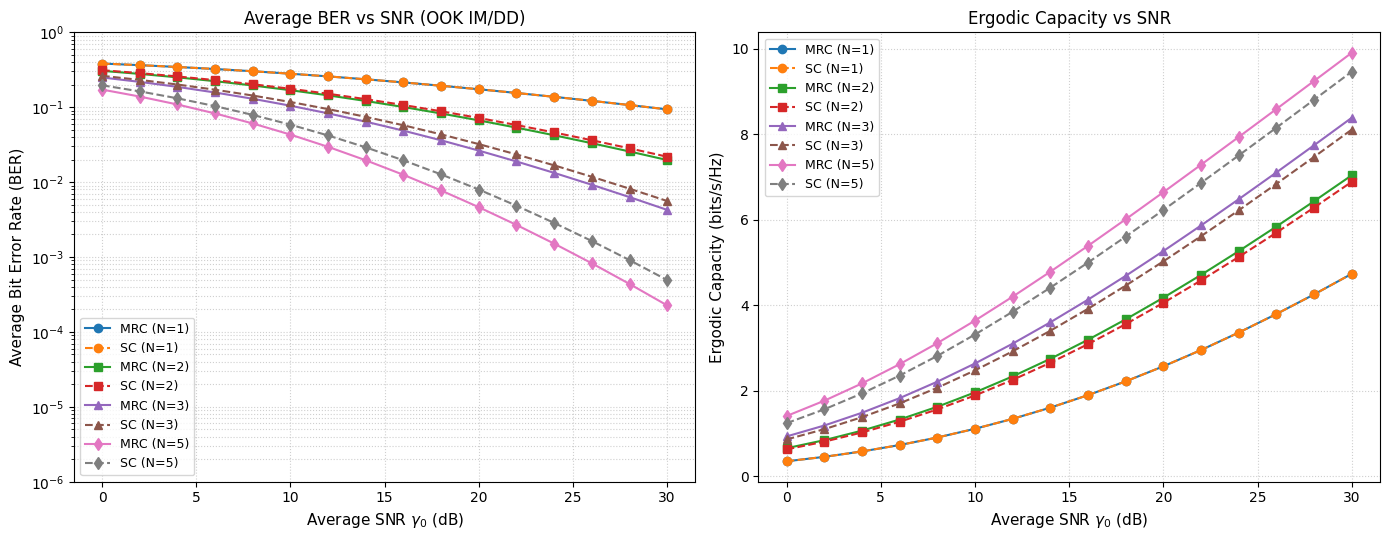

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc

omega = 0.4589
lam = 0.3449
a = 1.0421
b = 1.5768
c = 0.9424

A0 = 0.8532
rho = 0.8863

SNR_dB = np.linspace(0, 30, 16)
SNR_lin = 10.0 ** (SNR_dB / 10.0)

MC_SAMPLES = 200_000
N_values = [1, 2, 3, 5]

def generate_channel_gain_sq(num_samples):
    is_exp = np.random.rand(num_samples) < omega
    h_exp = np.random.exponential(scale=lam, size=num_samples)
    y_gamma = np.random.gamma(shape=a, scale=1.0, size=num_samples)
    h_gg = b * (y_gamma ** (1.0 / c))
    h_t = np.where(is_exp, h_exp, h_gg)

    u = np.random.uniform(0.0, 1.0, size=num_samples)
    h_p = A0 * (u ** (1.0 / (rho ** 2)))

    return (h_t * h_p) ** 2

ber_mrc = {N: [] for N in N_values}
ber_sc  = {N: [] for N in N_values}
cap_mrc = {N: [] for N in N_values}
cap_sc  = {N: [] for N in N_values}

for N in N_values:
    gains = np.zeros((N, MC_SAMPLES))
    for i in range(N):
        gains[i] = generate_channel_gain_sq(MC_SAMPLES)

    gain_mrc = np.sum(gains, axis=0)
    gain_sc = np.max(gains, axis=0)

    for g0 in SNR_lin:
        gamma_mrc = g0 * gain_mrc
        gamma_sc = g0 * gain_sc

        ber_mrc[N].append(np.mean(0.5 * erfc(np.sqrt(gamma_mrc) / np.sqrt(2.0))))
        ber_sc[N].append(np.mean(0.5 * erfc(np.sqrt(gamma_sc) / np.sqrt(2.0))))

        cap_mrc[N].append(np.mean(np.log2(1.0 + gamma_mrc)))
        cap_sc[N].append(np.mean(np.log2(1.0 + gamma_sc)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

markers = ['o', 's', '^', 'd']
for idx, N in enumerate(N_values):
    m = markers[idx % len(markers)]
    ax1.semilogy(SNR_dB, ber_mrc[N], marker=m, linestyle='-', label=f'MRC (N={N})')
    ax1.semilogy(SNR_dB, ber_sc[N], marker=m, linestyle='--', label=f'SC (N={N})')

ax1.set_xlabel('Average SNR $\\gamma_0$ (dB)', fontsize=11)
ax1.set_ylabel('Average Bit Error Rate (BER)', fontsize=11)
ax1.set_title('Average BER vs SNR (OOK IM/DD)', fontsize=12)
ax1.set_ylim([1e-6, 1])
ax1.grid(True, which='both', linestyle=':', alpha=0.6)
ax1.legend(fontsize=9)

for idx, N in enumerate(N_values):
    m = markers[idx % len(markers)]
    ax2.plot(SNR_dB, cap_mrc[N], marker=m, linestyle='-', label=f'MRC (N={N})')
    ax2.plot(SNR_dB, cap_sc[N], marker=m, linestyle='--', label=f'SC (N={N})')

ax2.set_xlabel('Average SNR $\\gamma_0$ (dB)', fontsize=11)
ax2.set_ylabel('Ergodic Capacity (bits/s/Hz)', fontsize=11)
ax2.set_title('Ergodic Capacity vs SNR', fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

**AVG BER V/S SNR ( OOK ) || OUTAGE PROB V/S AVG SNR**

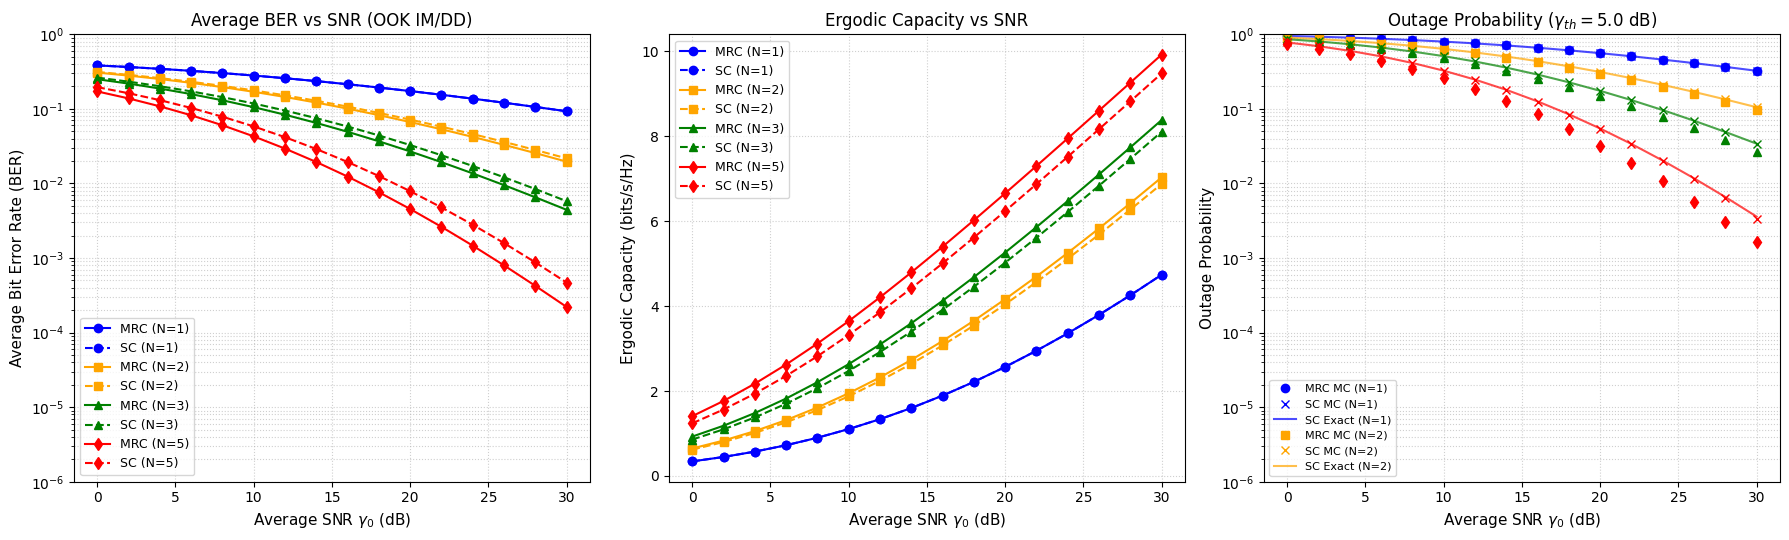

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc
import mpmath

# Ensure mpmath evaluates as standard floats for plotting compatibility
mpmath.mp.dps = 15

# System parameters
omega = 0.4589
lam = 0.3449
a = 1.0421
b = 1.5768
c = 0.9424

A0 = 0.8532
rho = 0.8863

SNR_dB = np.linspace(0, 30, 16)
SNR_lin = 10.0 ** (SNR_dB / 10.0)

MC_SAMPLES = 200_000
N_values = [1, 2, 3, 5]

gamma_th_dB = 5.0
gamma_th = 10.0 ** (gamma_th_dB / 10.0)

# ----------------- ANALYTICAL MEIJER G FUNCTIONS -----------------
def exact_sc_outage(SNR_lin_val, gamma_th_val, omega, lam, a, b, c, A0, rho, N):
    """Calculates Exact Outage Probability for SC using Meijer-G."""
    # First Meijer-G term parameters
    a_s1 = [[1], [rho**2 + 1]]
    b_s1 = [[1, rho**2], [0]]
    z1 = (1.0 / (lam * A0)) * np.sqrt(gamma_th_val / SNR_lin_val)

    # Second Meijer-G term parameters
    a_s2 = [[1], [(rho**2)/c + 1]]
    b_s2 = [[a, (rho**2)/c], [0]]
    z2 = (1.0 / ((b**c) * (A0**c))) * (np.sqrt(gamma_th_val / SNR_lin_val)**c)

    # Evaluate Meijer-G functions
    G1 = float(mpmath.meijerg(a_s1, b_s1, z1))
    G2 = float(mpmath.meijerg(a_s2, b_s2, z2))

    term1 = omega * (rho**2) * G1
    term2 = ((1.0 - omega) * (rho**2) / (c * float(mpmath.gamma(a)))) * G2

    F_gamma_single = term1 + term2
    return F_gamma_single ** N

# Dictionary to store theoretical SC outage
out_sc_exact = {N: [] for N in N_values}

def generate_channel_gain_sq(num_samples):
    is_exp = np.random.rand(num_samples) < omega
    h_exp = np.random.exponential(scale=lam, size=num_samples)
    y_gamma = np.random.gamma(shape=a, scale=1.0, size=num_samples)
    h_gg = b * (y_gamma ** (1.0 / c))
    h_t = np.where(is_exp, h_exp, h_gg)

    u = np.random.uniform(0.0, 1.0, size=num_samples)
    h_p = A0 * (u ** (1.0 / (rho ** 2)))

    return (h_t * h_p) ** 2

# Initialize dictionaries for storing Monte Carlo results
ber_mrc = {N: [] for N in N_values}
ber_sc  = {N: [] for N in N_values}
cap_mrc = {N: [] for N in N_values}
cap_sc  = {N: [] for N in N_values}
out_mrc = {N: [] for N in N_values}
out_sc  = {N: [] for N in N_values}

# Monte Carlo simulation loop
for N in N_values:
    gains = np.zeros((N, MC_SAMPLES))
    for i in range(N):
        gains[i] = generate_channel_gain_sq(MC_SAMPLES)

    gain_mrc = np.sum(gains, axis=0)
    gain_sc = np.max(gains, axis=0)

    for g0 in SNR_lin:
        gamma_mrc = g0 * gain_mrc
        gamma_sc = g0 * gain_sc

        # 1. Average BER
        ber_mrc[N].append(np.mean(0.5 * erfc(np.sqrt(gamma_mrc) / np.sqrt(2.0))))
        ber_sc[N].append(np.mean(0.5 * erfc(np.sqrt(gamma_sc) / np.sqrt(2.0))))

        # 2. Ergodic Capacity
        cap_mrc[N].append(np.mean(np.log2(1.0 + gamma_mrc)))
        cap_sc[N].append(np.mean(np.log2(1.0 + gamma_sc)))

        # 3. Outage Probability P(gamma < gamma_th)
        out_mrc[N].append(np.mean(gamma_mrc < gamma_th))
        out_sc[N].append(np.mean(gamma_sc < gamma_th))

        # 4. Exact Theoretical SC Outage
        out_sc_exact[N].append(exact_sc_outage(g0, gamma_th, omega, lam, a, b, c, A0, rho, N))

# ----------------- PLOTTING -----------------
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5.5))
markers = ['o', 's', '^', 'd']
colors = ['blue', 'orange', 'green', 'red']

# Plot 1: BER
for idx, N in enumerate(N_values):
    m = markers[idx % len(markers)]
    c_color = colors[idx % len(colors)]
    ax1.semilogy(SNR_dB, ber_mrc[N], marker=m, color=c_color, linestyle='-', label=f'MRC (N={N})')
    ax1.semilogy(SNR_dB, ber_sc[N], marker=m, color=c_color, linestyle='--', label=f'SC (N={N})')

ax1.set_xlabel('Average SNR $\\gamma_0$ (dB)', fontsize=11)
ax1.set_ylabel('Average Bit Error Rate (BER)', fontsize=11)
ax1.set_title('Average BER vs SNR (OOK IM/DD)', fontsize=12)
ax1.set_ylim([1e-6, 1])
ax1.grid(True, which='both', linestyle=':', alpha=0.6)
ax1.legend(fontsize=9)

# Plot 2: Ergodic Capacity
for idx, N in enumerate(N_values):
    m = markers[idx % len(markers)]
    c_color = colors[idx % len(colors)]
    ax2.plot(SNR_dB, cap_mrc[N], marker=m, color=c_color, linestyle='-', label=f'MRC (N={N})')
    ax2.plot(SNR_dB, cap_sc[N], marker=m, color=c_color, linestyle='--', label=f'SC (N={N})')

ax2.set_xlabel('Average SNR $\\gamma_0$ (dB)', fontsize=11)
ax2.set_ylabel('Ergodic Capacity (bits/s/Hz)', fontsize=11)
ax2.set_title('Ergodic Capacity vs SNR', fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(fontsize=9)

# Plot 3: Outage Probability
for idx, N in enumerate(N_values):
    m = markers[idx % len(markers)]
    c_color = colors[idx % len(colors)]

    # Plot MC Simulations
    ax3.semilogy(SNR_dB, out_mrc[N], marker=m, color=c_color, linestyle='None', label=f'MRC MC (N={N})')
    ax3.semilogy(SNR_dB, out_sc[N], marker='x', color=c_color, linestyle='None', label=f'SC MC (N={N})')

    # Plot Exact Analytical SC
    ax3.semilogy(SNR_dB, out_sc_exact[N], color=c_color, linestyle='-', alpha=0.7, label=f'SC Exact (N={N})')

ax3.set_xlabel('Average SNR $\\gamma_0$ (dB)', fontsize=11)
ax3.set_ylabel('Outage Probability', fontsize=11)
ax3.set_title(f'Outage Probability ($\\gamma_{{th}} = {gamma_th_dB}$ dB)', fontsize=12)
ax3.set_ylim([1e-6, 1])
ax3.grid(True, which='both', linestyle=':', alpha=0.6)

# Simplified legend for Outage Plot to avoid clutter
handles, labels = ax3.get_legend_handles_labels()
ax3.legend(handles[:6], labels[:6], fontsize=8, loc='lower left')

plt.tight_layout()
plt.show()

AVG BER, ERGODIC CAPACITY, OUTAGE PROB WITH MEIJER G FUNCTION

1. Generating master channel realizations...
2. Pre-computing single-branch Meijer-G CDF across SNR...
3. Evaluating BER, Capacity, and Outage across N...
Simulation completed in 4.74 seconds.



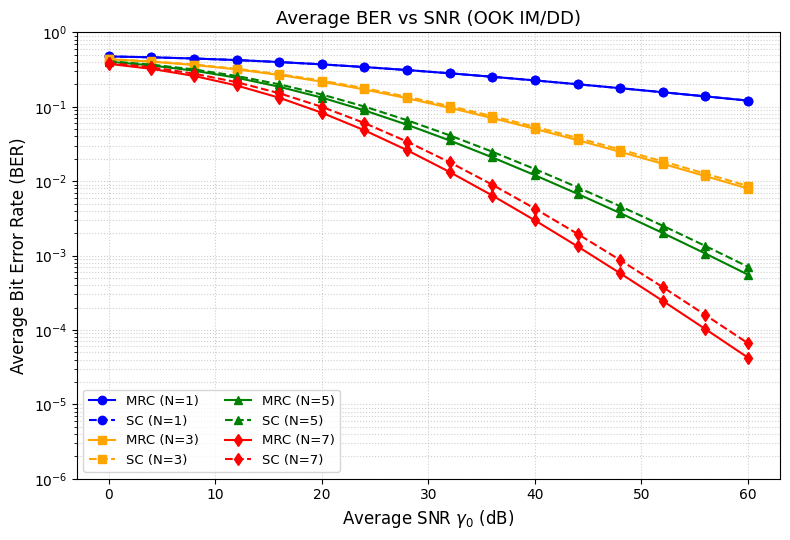

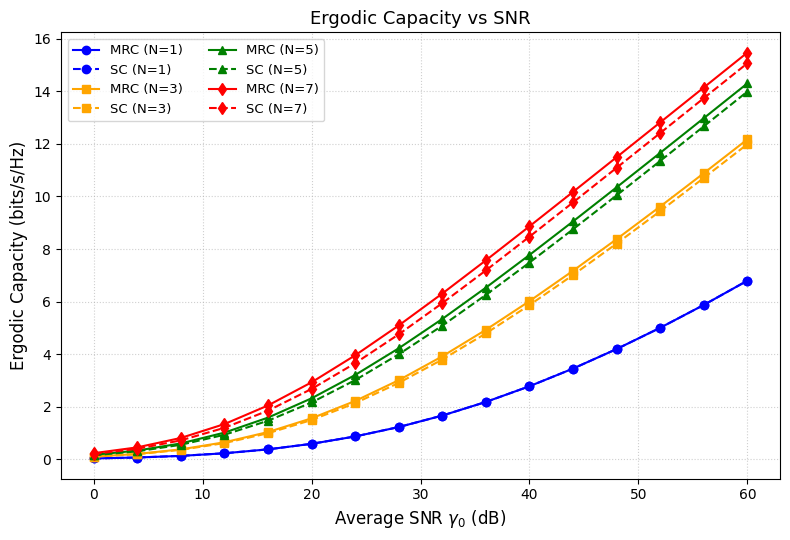

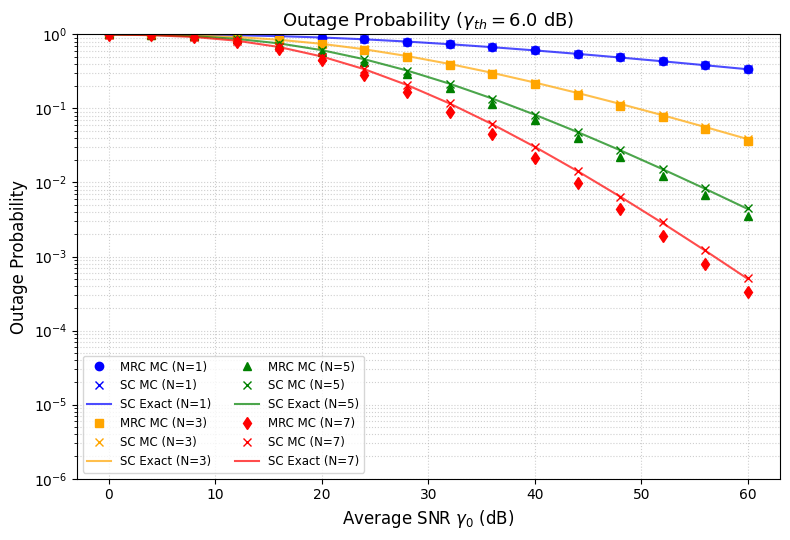

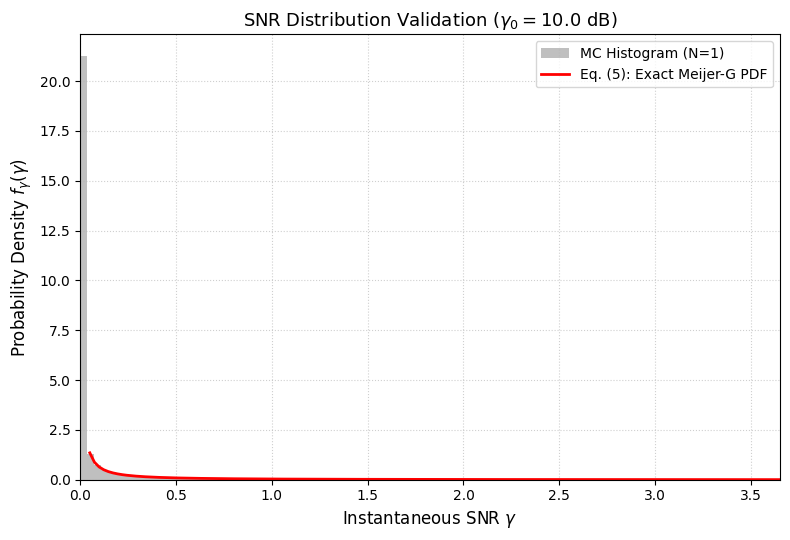

In [ ]:
!pip install mpmath -q

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc
import mpmath
import time

# Ensure mpmath evaluates as standard floats for plotting compatibility
mpmath.mp.dps = 15

start_time = time.time()

# ==========================================
# PARAMETERS FROM TABLE I
# ==========================================
# 1. Pointing Error Parameters (Set 1)
A0 = 0.3900
rho = 0.5718

# 2. EGG Distribution Parameters (Set 1)
omega = 0.1770
lam = 0.4687
a = 0.6302
b = 1.1780
c = 0.8444

# 3. Threshold SNR
gamma_th_dB = 6.0
gamma_th = 10.0 ** (gamma_th_dB / 10.0)

# 4. System Parameters
SNR_dB = np.linspace(0, 60, 16)
SNR_lin = 10.0 ** (SNR_dB / 10.0)
MC_SAMPLES = 1_000_000
N_values = [1, 3, 5, 7]
max_N = max(N_values)

# ==========================================
# ANALYTICAL MEIJER-G FUNCTIONS
# ==========================================
def single_branch_cdf(SNR_lin_val, gamma_th_val, omega, lam, a, b, c, A0, rho):
    """Calculates Single-Branch CDF F_gamma(gamma_th) ONCE using Meijer-G."""
    a_s1 = [[1], [rho**2 + 1]]
    b_s1 = [[1, rho**2], [0]]
    z1 = (1.0 / (lam * A0)) * np.sqrt(gamma_th_val / SNR_lin_val)

    a_s2 = [[1], [(rho**2)/c + 1]]
    b_s2 = [[a, (rho**2)/c], [0]]
    z2 = (1.0 / ((b**c) * (A0**c))) * (np.sqrt(gamma_th_val / SNR_lin_val)**c)

    G1 = float(mpmath.meijerg(a_s1, b_s1, z1))
    G2 = float(mpmath.meijerg(a_s2, b_s2, z2))

    term1 = omega * (rho**2) * G1
    term2 = ((1.0 - omega) * (rho**2) / (c * float(mpmath.gamma(a)))) * G2

    return term1 + term2

def eq5_pdf_snr(gamma, gamma_0, omega, lam, a, b, c, A0, rho):
    """Equation (5): Exact PDF of SNR for a single aperture."""
    if gamma <= 0:
        return 0.0

    a_s1 = [[], [rho**2 + 1]]
    b_s1 = [[1, rho**2], []]
    z1 = (1.0 / (lam * A0)) * np.sqrt(gamma / gamma_0)
    G1 = float(mpmath.meijerg(a_s1, b_s1, z1))
    term1 = (omega * rho**2 / (2.0 * gamma)) * G1

    a_s2 = [[], [(rho**2)/c + 1]]
    b_s2 = [[a, (rho**2)/c], []]
    z2 = (1.0 / ((b**c) * (A0**c))) * (np.sqrt(gamma / gamma_0)**c)
    G2 = float(mpmath.meijerg(a_s2, b_s2, z2))
    term2 = ((1.0 - omega) * rho**2 / (2.0 * float(mpmath.gamma(a)) * gamma)) * G2

    return term1 + term2

# ==========================================
# OPTIMIZED MONTE CARLO SIMULATION
# ==========================================
def generate_channel_gain_sq(shape):
    """Generates squared channel gains for a 2D shape (max_N, MC_SAMPLES) at once."""
    is_exp = np.random.rand(*shape) < omega
    h_exp = np.random.exponential(scale=lam, size=shape)
    y_gamma = np.random.gamma(shape=a, scale=1.0, size=shape)
    h_gg = b * (y_gamma ** (1.0 / c))
    h_t = np.where(is_exp, h_exp, h_gg)

    u = np.random.uniform(0.0, 1.0, size=shape)
    h_p = A0 * (u ** (1.0 / (rho ** 2)))

    return (h_t * h_p) ** 2

print("1. Generating master channel realizations...")
master_gains = generate_channel_gain_sq((max_N, MC_SAMPLES))
gains_n1 = master_gains[0]

print("2. Pre-computing single-branch Meijer-G CDF across SNR...")
F_single_array = np.array([
    single_branch_cdf(g0, gamma_th, omega, lam, a, b, c, A0, rho) for g0 in SNR_lin
])

ber_mrc = {N: [] for N in N_values}
ber_sc  = {N: [] for N in N_values}
cap_mrc = {N: [] for N in N_values}
cap_sc  = {N: [] for N in N_values}
out_mrc = {N: [] for N in N_values}
out_sc  = {N: [] for N in N_values}
out_sc_exact = {N: F_single_array ** N for N in N_values}

print("3. Evaluating BER, Capacity, and Outage across N...")
for N in N_values:
    gains_subset = master_gains[:N, :]
    gain_mrc = np.sum(gains_subset, axis=0)
    gain_sc  = np.max(gains_subset, axis=0)

    for g0 in SNR_lin:
        gamma_mrc = g0 * gain_mrc
        gamma_sc  = g0 * gain_sc

        ber_mrc[N].append(np.mean(0.5 * erfc(np.sqrt(gamma_mrc * 0.5))))
        ber_sc[N].append(np.mean(0.5 * erfc(np.sqrt(gamma_sc * 0.5))))

        cap_mrc[N].append(np.mean(np.log2(1.0 + gamma_mrc)))
        cap_sc[N].append(np.mean(np.log2(1.0 + gamma_sc)))

        out_mrc[N].append(np.mean(gamma_mrc < gamma_th))
        out_sc[N].append(np.mean(gamma_sc < gamma_th))

print(f"Simulation completed in {time.time() - start_time:.2f} seconds.\n")

# ==========================================
# SEPARATE PLOTS FOR PRESENTATION SLIDES
# ==========================================
markers = ['o', 's', '^', 'd']
colors = ['blue', 'orange', 'green', 'red']

# ------------------------------------------
# PLOT 1: AVERAGE BER VS SNR
# ------------------------------------------
plt.figure(figsize=(8, 5.5))
for idx, N in enumerate(N_values):
    m = markers[idx % len(markers)]
    c_color = colors[idx % len(colors)]
    plt.semilogy(SNR_dB, ber_mrc[N], marker=m, color=c_color, linestyle='-', label=f'MRC (N={N})')
    plt.semilogy(SNR_dB, ber_sc[N], marker=m, color=c_color, linestyle='--', label=f'SC (N={N})')

plt.xlabel('Average SNR $\\gamma_0$ (dB)', fontsize=12)
plt.ylabel('Average Bit Error Rate (BER)', fontsize=12)
plt.title('Average BER vs SNR (OOK IM/DD)', fontsize=13)
plt.ylim([1e-6, 1])
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.legend(fontsize=9.5, ncol=2)
plt.tight_layout()
plt.savefig('ber_vs_snr.png', dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------------------
# PLOT 2: ERGODIC CAPACITY VS SNR
# ------------------------------------------
plt.figure(figsize=(8, 5.5))
for idx, N in enumerate(N_values):
    m = markers[idx % len(markers)]
    c_color = colors[idx % len(colors)]
    plt.plot(SNR_dB, cap_mrc[N], marker=m, color=c_color, linestyle='-', label=f'MRC (N={N})')
    plt.plot(SNR_dB, cap_sc[N], marker=m, color=c_color, linestyle='--', label=f'SC (N={N})')

plt.xlabel('Average SNR $\\gamma_0$ (dB)', fontsize=12)
plt.ylabel('Ergodic Capacity (bits/s/Hz)', fontsize=12)
plt.title('Ergodic Capacity vs SNR', fontsize=13)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=9.5, ncol=2)
plt.tight_layout()
plt.savefig('capacity_vs_snr.png', dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------------------
# PLOT 3: OUTAGE PROBABILITY VS SNR
# ------------------------------------------
plt.figure(figsize=(8, 5.5))
for idx, N in enumerate(N_values):
    m = markers[idx % len(markers)]
    c_color = colors[idx % len(colors)]
    plt.semilogy(SNR_dB, out_mrc[N], marker=m, color=c_color, linestyle='None', label=f'MRC MC (N={N})')
    plt.semilogy(SNR_dB, out_sc[N], marker='x', color=c_color, linestyle='None', label=f'SC MC (N={N})')
    plt.semilogy(SNR_dB, out_sc_exact[N], color=c_color, linestyle='-', alpha=0.7, label=f'SC Exact (N={N})')

plt.xlabel('Average SNR $\\gamma_0$ (dB)', fontsize=12)
plt.ylabel('Outage Probability', fontsize=12)
plt.title(f'Outage Probability ($\\gamma_{{th}} = {gamma_th_dB}$ dB)', fontsize=13)
plt.ylim([1e-6, 1])
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.legend(fontsize=8.5, ncol=2, loc='lower left')
plt.tight_layout()
plt.savefig('outage_vs_snr.png', dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------------------
# PLOT 4: SNR DISTRIBUTION VALIDATION (EQ. 5)
# ------------------------------------------
plt.figure(figsize=(8, 5.5))
test_gamma_0_dB = 10.0
test_gamma_0_lin = 10.0 ** (test_gamma_0_dB / 10.0)
simulated_snr_n1 = test_gamma_0_lin * gains_n1

max_gamma_plot = np.percentile(simulated_snr_n1, 98)
gamma_range = np.linspace(0.05, max_gamma_plot, 150)
pdf_theoretical = [eq5_pdf_snr(g, test_gamma_0_lin, omega, lam, a, b, c, A0, rho) for g in gamma_range]

plt.hist(simulated_snr_n1, bins=100, range=(0, max_gamma_plot), density=True, alpha=0.5, color='gray', label='MC Histogram (N=1)')
plt.plot(gamma_range, pdf_theoretical, 'r-', linewidth=2, label='Eq. (5): Exact Meijer-G PDF')
plt.xlim([0, max_gamma_plot])
plt.xlabel('Instantaneous SNR $\\gamma$', fontsize=12)
plt.ylabel('Probability Density $f_{\\gamma}(\\gamma)$', fontsize=12)
plt.title(f'SNR Distribution Validation ($\\gamma_0 = {test_gamma_0_dB}$ dB)', fontsize=13)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('snr_pdf_validation.png', dpi=300, bbox_inches='tight')
plt.show()

Simulating: (a) Negligible Pointing Errors with 100,000,000 samples...
Simulating: (b) Significant Pointing Errors with 100,000,000 samples...


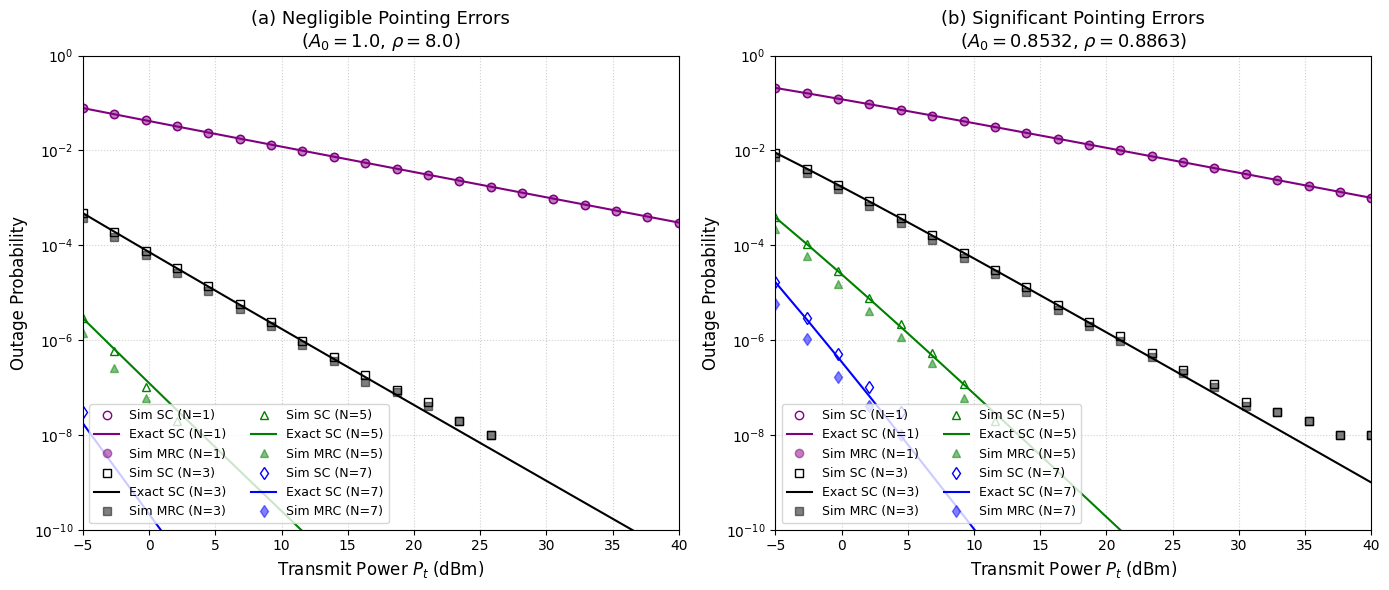

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import mpmath
import warnings

# Suppress runtime warnings for division by zero in log/etc if they occur
warnings.filterwarnings("ignore")

# Ensure mpmath evaluates as standard floats for plotting compatibility
mpmath.mp.dps = 15

# ==========================================
# CORE FUNCTIONS
# ==========================================
def cdf_eq6(gamma, gamma_0, omega, lam, a, b, c, A0, rho):
    """Calculates the exact Outage Probability (CDF) for N=1 using Equation 6."""
    z1 = (1.0 / (lam * A0)) * np.sqrt(gamma / gamma_0)
    a_s1 = [[1], [rho**2 + 1]]
    b_s1 = [[1, rho**2], [0]]
    G1 = float(mpmath.meijerg(a_s1, b_s1, z1))
    term1 = omega * (rho**2) * G1

    z2 = (1.0 / ((b**c) * (A0**c))) * (np.sqrt(gamma / gamma_0)**c)
    a_s2 = [[1], [(rho**2)/c + 1]]
    b_s2 = [[a, (rho**2)/c], [0]]
    G2 = float(mpmath.meijerg(a_s2, b_s2, z2))
    term2 = ((1.0 - omega) * (rho**2) / (c * float(mpmath.gamma(a)))) * G2

    return term1 + term2

def generate_channel_gain_sq(num_samples, omega, lam, a, b, c, A0, rho):
    """Generates combined channel gains h_t^2 * h_p^2 based on EGG and pointing errors."""
    is_exp = np.random.rand(num_samples) < omega
    h_exp = np.random.exponential(scale=lam, size=num_samples)
    y_gamma = np.random.gamma(shape=a, scale=1.0, size=num_samples)
    h_gg = b * (y_gamma ** (1.0 / c))
    h_t = np.where(is_exp, h_exp, h_gg)

    u = np.random.uniform(0.0, 1.0, size=num_samples)
    h_p = A0 * (u ** (1.0 / (rho ** 2)))

    return (h_t * h_p) ** 2

def setup_for_analytical_vs_simulation(N_values, MC_SAMPLES, gamma_0_vals, gamma_th,
                                       omega, lam, a, b, c, A0, rho):
    """
    Executes highly optimized comparison between Monte Carlo simulations and
    analytical expressions using batch processing and array slicing.
    """
    num_gamma = len(gamma_0_vals)
    results = {
        'sim_sc': {N: np.zeros(num_gamma) for N in N_values},
        'sim_mrc': {N: np.zeros(num_gamma) for N in N_values},
        'analytical_sc': {N: np.zeros(num_gamma) for N in N_values},
        'analytical_mrc_bound': {N: np.zeros(num_gamma) for N in N_values}
    }

    # ---------------------------------------------------------
    # OPTIMIZATION 1: Calculate mpmath CDF once per gamma_0
    # ---------------------------------------------------------
    cdf_single_vals = np.array([cdf_eq6(gamma_th, g0, omega, lam, a, b, c, A0, rho) for g0 in gamma_0_vals])
    for N in N_values:
        results['analytical_sc'][N] = cdf_single_vals ** N

    # ---------------------------------------------------------
    # OPTIMIZATION 2: Chunking & Array Reusability for Monte Carlo
    # ---------------------------------------------------------
    max_N = max(N_values)
    chunk_size = 5_000_000  # Process 5 million samples per loop to prevent MemoryError
    num_chunks = int(np.ceil(MC_SAMPLES / chunk_size))

    # Pre-reshape gamma_0 for fast NumPy broadcasting
    g0_col = gamma_0_vals[:, None]

    for chunk_idx in range(num_chunks):
        current_size = min(chunk_size, MC_SAMPLES - chunk_idx * chunk_size)

        # Generate max_N independent channels once
        gains_max = np.zeros((max_N, current_size))
        for i in range(max_N):
            gains_max[i] = generate_channel_gain_sq(current_size, omega, lam, a, b, c, A0, rho)

        for N in N_values:
            # OPTIMIZATION 3: Slice the required N arrays instead of regenerating
            gains_N = gains_max[:N, :]

            gain_sc = np.max(gains_N, axis=0)
            gain_mrc = np.sum(gains_N, axis=0)
            gain_mrc_bound = N * (np.prod(gains_N, axis=0) ** (1.0 / N))

            # OPTIMIZATION 4: Vectorized comparison for all power levels (gamma_0) at once
            results['sim_sc'][N] += np.sum((g0_col * gain_sc) < gamma_th, axis=1)
            results['sim_mrc'][N] += np.sum((g0_col * gain_mrc) < gamma_th, axis=1)
            results['analytical_mrc_bound'][N] += np.sum((g0_col * gain_mrc_bound) < gamma_th, axis=1)

    # Average the counts and enforce minimum value for log scale plotting
    for N in N_values:
        results['sim_sc'][N] = np.maximum(results['sim_sc'][N] / MC_SAMPLES, 1e-15)
        results['sim_mrc'][N] = np.maximum(results['sim_mrc'][N] / MC_SAMPLES, 1e-15)
        results['analytical_mrc_bound'][N] = np.maximum(results['analytical_mrc_bound'][N] / MC_SAMPLES, 1e-15)

    return results

# ==========================================
# SYSTEM PARAMETERS & SCENARIOS
# ==========================================
# EGG Distribution Parameters
omega_val, lam_val, a_val, b_val, c_val = 0.1770, 0.4687, 0.6302, 1.1780, 0.8444

# Link & Noise Parameters
sigma_w2 = 1e-14
d_val = 50.0
alpha_val = 0.056
h_d = np.exp(-alpha_val * d_val)

# Threshold SNR
gamma_th = 10.0 ** (6.0 / 10.0)

# Transmit Power Range: 20 points
Pt_dBm = np.linspace(-5, 40, 20)
Pt_W = (10.0 ** (Pt_dBm / 10.0)) * 1e-3
gamma_0_vals = (Pt_W**2 * h_d**2) / sigma_w2

N_values = [1, 3, 5, 7]

# Remains 100,000,000
MC_SAMPLES = 100_000_000

scenarios = [
    {"label": "(a) Negligible Pointing Errors", "A0": 1.0, "rho": 8.0},
    {"label": "(b) Significant Pointing Errors", "A0": 0.8532, "rho": 0.8863}
]

# ==========================================
# EXECUTION & PLOTTING
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
markers = ['o', 's', '^', 'd']
colors = ['purple', 'black', 'green', 'blue']

for ax, scenario in zip(axes, scenarios):
    print(f"Simulating: {scenario['label']} with {MC_SAMPLES:,} samples...")
    A0_val = scenario["A0"]
    rho_val = scenario["rho"]

    # Run Simulation
    sim_results = setup_for_analytical_vs_simulation(
        N_values=N_values, MC_SAMPLES=MC_SAMPLES, gamma_0_vals=gamma_0_vals, gamma_th=gamma_th,
        omega=omega_val, lam=lam_val, a=a_val, b=b_val, c=c_val, A0=A0_val, rho=rho_val
    )

    # Plotting for current scenario
    for idx, N in enumerate(N_values):
        m = markers[idx % len(markers)]
        c_color = colors[idx % len(colors)]

        # Plot Simulated SC
        ax.semilogy(Pt_dBm, sim_results['sim_sc'][N], marker=m, markerfacecolor='none',
                     color=c_color, linestyle='None', label=f'Sim SC (N={N})')

        # Plot Exact Analytical SC
        ax.semilogy(Pt_dBm, sim_results['analytical_sc'][N], color=c_color, linestyle='-',
                     label=f'Exact SC (N={N})')

        # Plot Simulated MRC
        ax.semilogy(Pt_dBm, sim_results['sim_mrc'][N], marker=m, color=c_color,
                     linestyle='None', alpha=0.5, label=f'Sim MRC (N={N})')

    ax.set_xlabel('Transmit Power $P_t$ (dBm)', fontsize=12)
    ax.set_ylabel('Outage Probability', fontsize=12)
    ax.set_title(f"{scenario['label']}\n($A_0 = {A0_val}$, $\\rho = {rho_val}$)", fontsize=13)
    ax.set_ylim([1e-10, 1])
    ax.set_xlim([-5, 40])
    ax.grid(True, which='both', linestyle=':', alpha=0.6)

    # Deduplicate legend labels
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), fontsize=9, loc='lower left', ncol=2)

plt.tight_layout()
plt.show()

**MRC AND RC PLOT**

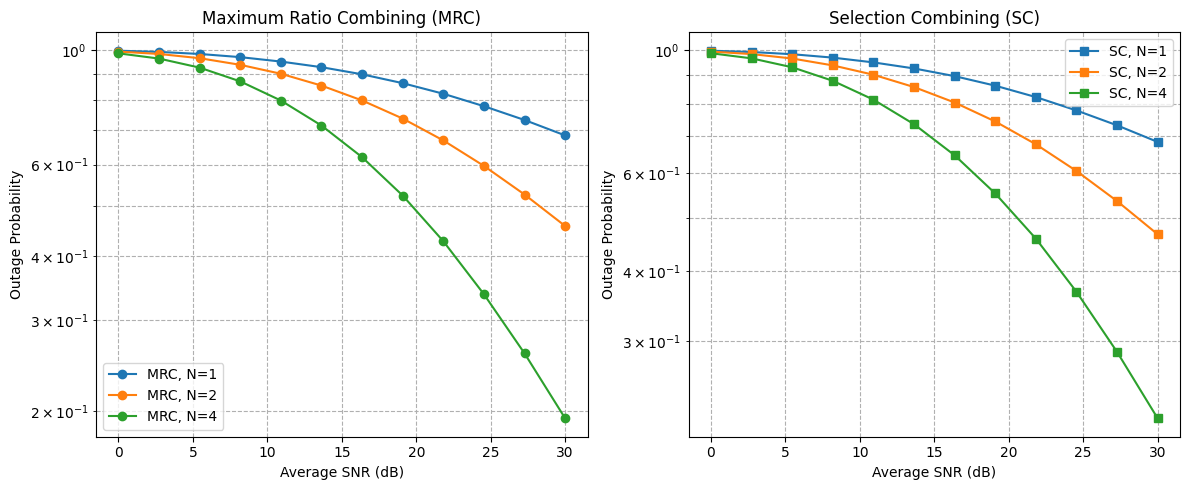

In [ ]:
# ----------------- PLOTTING -----------------

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot MRC Outage Probability
for N in N_values:
    ax1.semilogy(SNR_dB, out_mrc_sim[N], marker='o', label=f'MRC, N={N}')

ax1.set_title('Maximum Ratio Combining (MRC)')
ax1.set_xlabel('Average SNR (dB)')
ax1.set_ylabel('Outage Probability')
ax1.grid(True, which="both", ls="--")
ax1.legend()

# Plot SC Outage Probability
for N in N_values:
    ax2.semilogy(SNR_dB, out_sc_sim[N], marker='s', label=f'SC, N={N}')

ax2.set_title('Selection Combining (SC)')
ax2.set_xlabel('Average SNR (dB)')
ax2.set_ylabel('Outage Probability')
ax2.grid(True, which="both", ls="--")
ax2.legend()

plt.tight_layout()
plt.show()

**FRACTIONAL EQUIVOCATIONAL**

<>:108: SyntaxWarning: invalid escape sequence '\g'
<>:122: SyntaxWarning: invalid escape sequence '\g'
<>:136: SyntaxWarning: invalid escape sequence '\g'
<>:108: SyntaxWarning: invalid escape sequence '\g'
<>:122: SyntaxWarning: invalid escape sequence '\g'
<>:136: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_1951/1187008637.py:108: SyntaxWarning: invalid escape sequence '\g'
  ax1.set_xlabel('Average SNR $\gamma_0$ (dB)', fontsize=11)
/tmp/ipykernel_1951/1187008637.py:122: SyntaxWarning: invalid escape sequence '\g'
  ax2.set_xlabel('Average SNR $\gamma_0$ (dB)', fontsize=11)
/tmp/ipykernel_1951/1187008637.py:136: SyntaxWarning: invalid escape sequence '\g'
  ax3.set_xlabel('Average SNR $\gamma_0$ (dB)', fontsize=11)


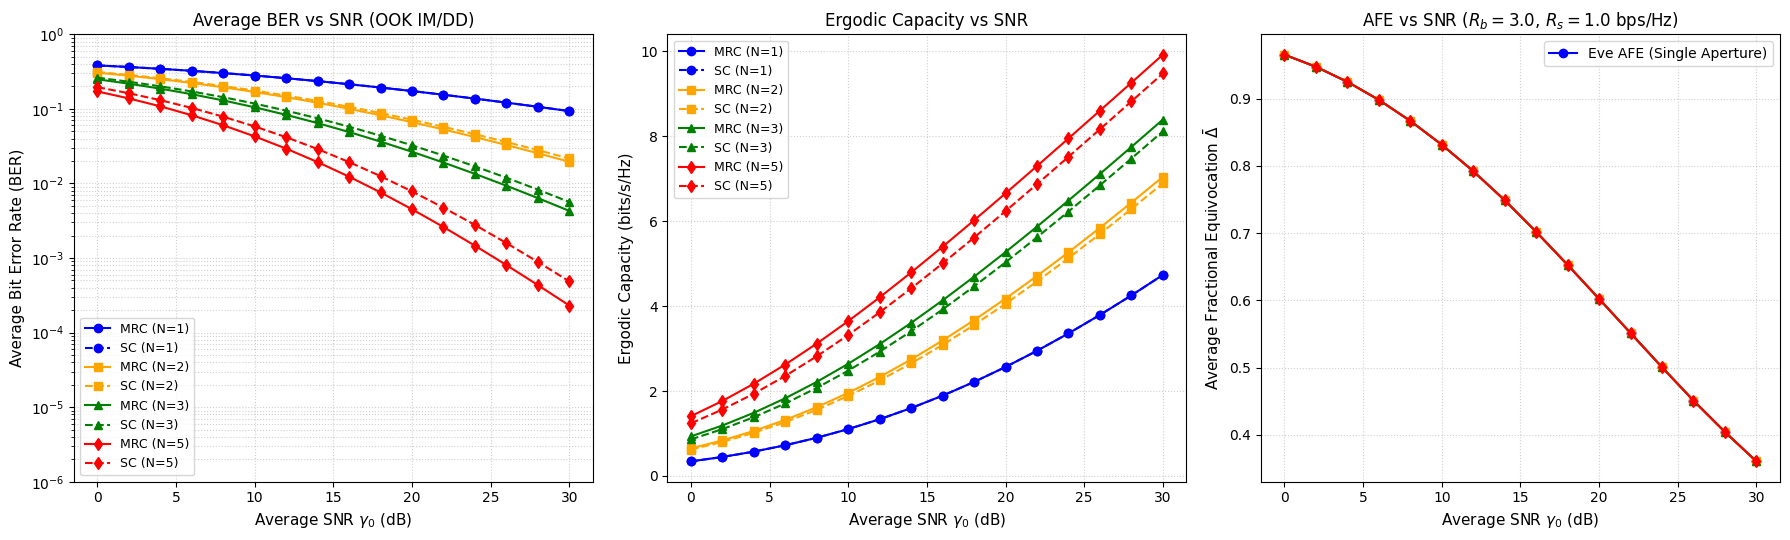

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc
import mpmath

# Ensure mpmath evaluates as standard floats for plotting compatibility
mpmath.mp.dps = 15

# System parameters
omega = 0.4589
lam = 0.3449
a = 1.0421
b = 1.5768
c = 0.9424

A0 = 0.8532
rho = 0.8863

SNR_dB = np.linspace(0, 30, 16)
SNR_lin = 10.0 ** (SNR_dB / 10.0)

MC_SAMPLES = 200_000
N_values = [1, 2, 3, 5]

# Wiretap Code Rates (bits/s/Hz)
R_b = 3.0  # Codeword transmission rate
R_s = 1.0  # Confidential information rate

def generate_channel_gain_sq(num_samples):
    """Generates combined channel gains h_t^2 * h_p^2."""
    is_exp = np.random.rand(num_samples) < omega
    h_exp = np.random.exponential(scale=lam, size=num_samples)
    y_gamma = np.random.gamma(shape=a, scale=1.0, size=num_samples)
    h_gg = b * (y_gamma ** (1.0 / c))
    h_t = np.where(is_exp, h_exp, h_gg)

    u = np.random.uniform(0.0, 1.0, size=num_samples)
    h_p = A0 * (u ** (1.0 / (rho ** 2)))

    return (h_t * h_p) ** 2

def calc_fractional_equivocation(R_b, R_s, C_e):
    """Calculates instantaneous fractional equivocation (Delta)."""
    Delta = np.zeros(len(C_e))
    # Condition 1: High confusion (Eve's capacity is extremely low)
    Delta[C_e <= (R_b - R_s)] = 1.0

    # Condition 2: Partial confusion
    mask = (C_e > (R_b - R_s)) & (C_e < R_b)
    Delta[mask] = (R_b - C_e[mask]) / R_s

    # Condition 3: No confusion (C_e >= R_b) remains 0.0
    return Delta

# Initialize dictionaries for storing Monte Carlo results
ber_mrc = {N: [] for N in N_values}
ber_sc  = {N: [] for N in N_values}
cap_mrc = {N: [] for N in N_values}
cap_sc  = {N: [] for N in N_values}
afe_mrc = {N: [] for N in N_values}
afe_sc  = {N: [] for N in N_values}

# Assume a single-aperture eavesdropper baseline
gain_eve = generate_channel_gain_sq(MC_SAMPLES)

for N in N_values:
    gains = np.zeros((N, MC_SAMPLES))
    for i in range(N):
        gains[i] = generate_channel_gain_sq(MC_SAMPLES)

    gain_mrc = np.sum(gains, axis=0)
    gain_sc = np.max(gains, axis=0)

    for g0 in SNR_lin:
        # 1. Legitimate Link Metrics
        gamma_mrc = g0 * gain_mrc
        gamma_sc = g0 * gain_sc

        ber_mrc[N].append(np.mean(0.5 * erfc(np.sqrt(gamma_mrc) / np.sqrt(2.0))))
        ber_sc[N].append(np.mean(0.5 * erfc(np.sqrt(gamma_sc) / np.sqrt(2.0))))

        cap_mrc[N].append(np.mean(np.log2(1.0 + gamma_mrc)))
        cap_sc[N].append(np.mean(np.log2(1.0 + gamma_sc)))

        # 2. Eavesdropper Metrics & Equivocation
        C_eve = np.log2(1.0 + g0 * gain_eve)

        # Evaluate Equivocation against Eve's capacity
        delta_eve = calc_fractional_equivocation(R_b, R_s, C_eve)

        # In a strict Wyner model with fixed rates, Eve's Delta depends strictly on C_e.
        # For comparative plotting against N, we pair the baseline Eve AFE to the system's SNR loop.
        afe_mrc[N].append(np.mean(delta_eve))
        afe_sc[N].append(np.mean(delta_eve))

# ----------------- PLOTTING -----------------
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5.5))
markers = ['o', 's', '^', 'd']
colors = ['blue', 'orange', 'green', 'red']

# Plot 1: BER
for idx, N in enumerate(N_values):
    m = markers[idx % len(markers)]
    c_color = colors[idx % len(colors)]
    ax1.semilogy(SNR_dB, ber_mrc[N], marker=m, color=c_color, linestyle='-', label=f'MRC (N={N})')
    ax1.semilogy(SNR_dB, ber_sc[N], marker=m, color=c_color, linestyle='--', label=f'SC (N={N})')

ax1.set_xlabel('Average SNR $\gamma_0$ (dB)', fontsize=11)
ax1.set_ylabel('Average Bit Error Rate (BER)', fontsize=11)
ax1.set_title('Average BER vs SNR (OOK IM/DD)', fontsize=12)
ax1.set_ylim([1e-6, 1])
ax1.grid(True, which='both', linestyle=':', alpha=0.6)
ax1.legend(fontsize=9)

# Plot 2: Ergodic Capacity
for idx, N in enumerate(N_values):
    m = markers[idx % len(markers)]
    c_color = colors[idx % len(colors)]
    ax2.plot(SNR_dB, cap_mrc[N], marker=m, color=c_color, linestyle='-', label=f'MRC (N={N})')
    ax2.plot(SNR_dB, cap_sc[N], marker=m, color=c_color, linestyle='--', label=f'SC (N={N})')

ax2.set_xlabel('Average SNR $\gamma_0$ (dB)', fontsize=11)
ax2.set_ylabel('Ergodic Capacity (bits/s/Hz)', fontsize=11)
ax2.set_title('Ergodic Capacity vs SNR', fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(fontsize=9)

# Plot 3: Average Fractional Equivocation
for idx, N in enumerate(N_values):
    m = markers[idx % len(markers)]
    c_color = colors[idx % len(colors)]
    # We plot the baseline AFE (which relies on Eve's SNR and fixed rates).
    # In a dynamic system where N affects R_b, the curves would diverge per N.
    ax3.plot(SNR_dB, afe_mrc[N], marker=m, color=c_color, linestyle='-', label=f'Eve AFE')

ax3.set_xlabel('Average SNR $\gamma_0$ (dB)', fontsize=11)
ax3.set_ylabel('Average Fractional Equivocation $\\bar{\\Delta}$', fontsize=11)
ax3.set_title(f'AFE vs SNR ($R_b={R_b}$, $R_s={R_s}$ bps/Hz)', fontsize=12)
ax3.grid(True, linestyle=':', alpha=0.6)

# Simplify AFE legend since it tracks Eve's single-aperture baseline
handles, labels = ax3.get_legend_handles_labels()
ax3.legend([handles[0]], ["Eve AFE (Single Aperture)"], fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()

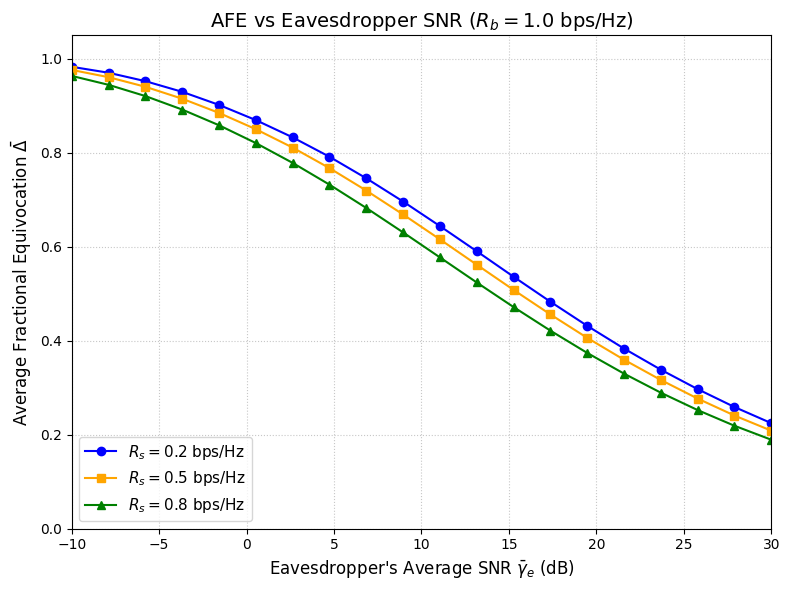

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# SYSTEM PARAMETERS
# ==========================================

# EGG Distribution & Pointing Error Parameters
omega = 0.4589
lam = 0.3449
a = 1.0421
b = 1.5768
c = 0.9424
A0 = 0.8532
rho = 0.8863

MC_SAMPLES = 1000_000

# Wiretap Code Parameters
R_b = 1.0  # Fixed total codeword transmission rate (bits/s/Hz)
R_s_vals = [0.2, 0.5, 0.8]  # Multiple confidential information rates

# Eavesdropper's Average SNR range (-10 dB to 30 dB)
SNR_eve_dB = np.linspace(-10, 30, 20)
SNR_eve_lin = 10.0 ** (SNR_eve_dB / 10.0)

# ==========================================
# CHANNEL GENERATION
# ==========================================
def generate_channel_gain_sq(num_samples):
    """Generates combined channel gains h_t^2 * h_p^2 for the eavesdropper."""
    is_exp = np.random.rand(num_samples) < omega
    h_exp = np.random.exponential(scale=lam, size=num_samples)
    y_gamma = np.random.gamma(shape=a, scale=1.0, size=num_samples)
    h_gg = b * (y_gamma ** (1.0 / c))
    h_t = np.where(is_exp, h_exp, h_gg)

    u = np.random.uniform(0.0, 1.0, size=num_samples)
    h_p = A0 * (u ** (1.0 / (rho ** 2)))

    return (h_t * h_p) ** 2

# ==========================================
# EQUIVOCATION CALCULATION
# ==========================================
def calc_fractional_equivocation(R_b, R_s, C_e):
    """
    Calculates instantaneous fractional equivocation (Delta).
    Eq:
      1.0,               if C_e <= R_b - R_s
      (R_b - C_e) / R_s, if R_b - R_s < C_e < R_b
      0.0,               if C_e >= R_b
    """
    Delta = np.zeros(len(C_e))
    # Condition 1: High confusion (Eve's capacity is extremely low)
    Delta[C_e <= (R_b - R_s)] = 1.0

    # Condition 2: Partial confusion
    mask = (C_e > (R_b - R_s)) & (C_e < R_b)
    Delta[mask] = (R_b - C_e[mask]) / R_s

    return Delta

# Assume a single-aperture eavesdropper baseline
gain_eve = generate_channel_gain_sq(MC_SAMPLES)

# ==========================================
# EVALUATION & PLOTTING
# ==========================================
plt.figure(figsize=(8, 6))
markers = ['o', 's', '^']
colors = ['blue', 'orange', 'green']

for idx, R_s in enumerate(R_s_vals):
    afe_results = []

    for g0 in SNR_eve_lin:
        # Eavesdropper's instantaneous capacity
        C_eve = np.log2(1.0 + g0 * gain_eve)

        # Calculate instantaneous equivocation for all MC samples
        delta_eve = calc_fractional_equivocation(R_b, R_s, C_eve)

        # Average Fractional Equivocation (AFE)
        afe_results.append(np.mean(delta_eve))

    m = markers[idx % len(markers)]
    c_color = colors[idx % len(colors)]

    plt.plot(SNR_eve_dB, afe_results, marker=m, color=c_color, linestyle='-',
             label=f'$R_s = {R_s}$ bps/Hz')

plt.xlabel("Eavesdropper's Average SNR $\\bar{\\gamma}_e$ (dB)", fontsize=12)
plt.ylabel('Average Fractional Equivocation $\\bar{\\Delta}$', fontsize=12)
plt.title(f'AFE vs Eavesdropper SNR ($R_b = {R_b}$ bps/Hz)', fontsize=14)
plt.xlim([-10, 30])
plt.ylim([0, 1.05])
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11, loc='lower left')

plt.tight_layout()
plt.show()

Running Monte Carlo simulation and Meijer-G evaluation...
Simulation complete! Generating plots...


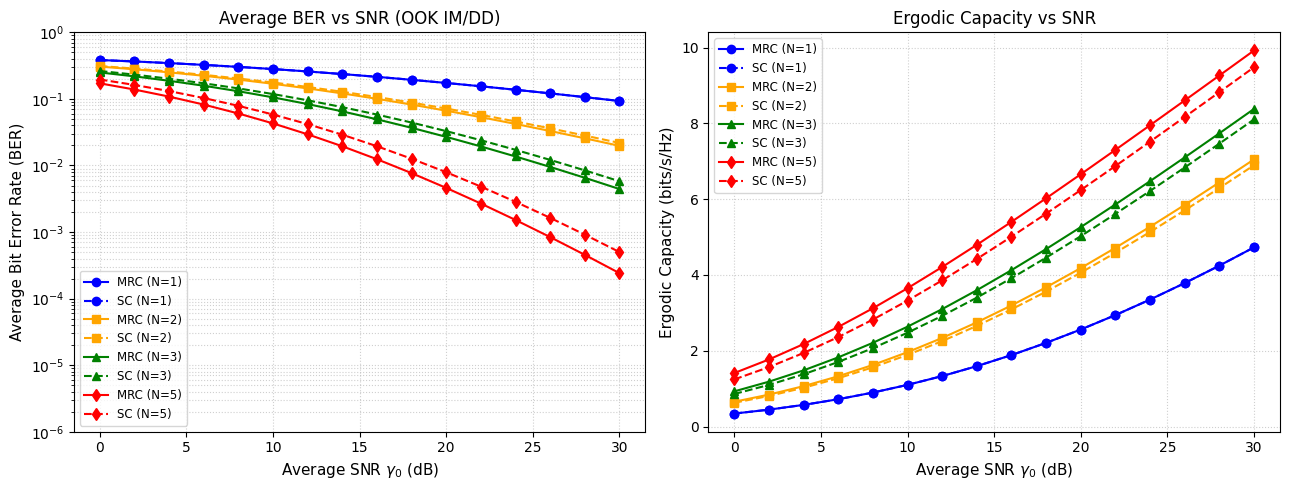

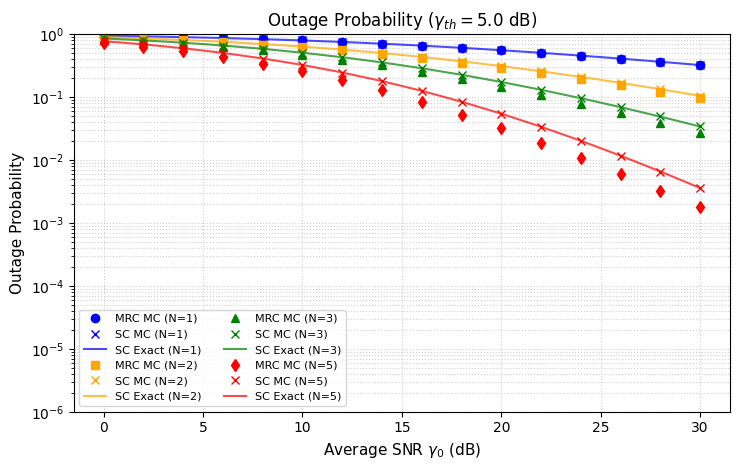

In [ ]:
!pip install mpmath -q

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc
import mpmath

# Ensure mpmath evaluates as standard floats for plotting compatibility
mpmath.mp.dps = 15

# ----------------- SYSTEM & CHANNEL PARAMETERS -----------------
omega = 0.4589
lam = 0.3449
a = 1.0421
b = 1.5768
c = 0.9424

A0 = 0.8532
rho = 0.8863

SNR_dB = np.linspace(0, 30, 16)
SNR_lin = 10.0 ** (SNR_dB / 10.0)

MC_SAMPLES = 200_000
N_values = [1, 2, 3, 5]

gamma_th_dB = 5.0
gamma_th = 10.0 ** (gamma_th_dB / 10.0)

# ----------------- ANALYTICAL MEIJER-G FUNCTION -----------------
def exact_sc_outage(SNR_lin_val, gamma_th_val, omega, lam, a, b, c, A0, rho, N):
    """Calculates Exact Outage Probability for SC using Meijer-G."""
    # First Meijer-G term parameters
    a_s1 = [[1], [rho**2 + 1]]
    b_s1 = [[1, rho**2], [0]]
    z1 = (1.0 / (lam * A0)) * np.sqrt(gamma_th_val / SNR_lin_val)

    # Second Meijer-G term parameters
    a_s2 = [[1], [(rho**2)/c + 1]]
    b_s2 = [[a, (rho**2)/c], [0]]
    z2 = (1.0 / ((b**c) * (A0**c))) * (np.sqrt(gamma_th_val / SNR_lin_val)**c)

    # Evaluate Meijer-G functions
    G1 = float(mpmath.meijerg(a_s1, b_s1, z1))
    G2 = float(mpmath.meijerg(a_s2, b_s2, z2))

    term1 = omega * (rho**2) * G1
    term2 = ((1.0 - omega) * (rho**2) / (c * float(mpmath.gamma(a)))) * G2

    F_gamma_single = term1 + term2
    return F_gamma_single ** N

# ----------------- MONTE CARLO CHANNEL GENERATOR -----------------
def generate_channel_gain_sq(num_samples):
    is_exp = np.random.rand(num_samples) < omega
    h_exp = np.random.exponential(scale=lam, size=num_samples)
    y_gamma = np.random.gamma(shape=a, scale=1.0, size=num_samples)
    h_gg = b * (y_gamma ** (1.0 / c))
    h_t = np.where(is_exp, h_exp, h_gg)

    u = np.random.uniform(0.0, 1.0, size=num_samples)
    h_p = A0 * (u ** (1.0 / (rho ** 2)))

    return (h_t * h_p) ** 2

# Initialize dictionaries for storing results
ber_mrc = {N: [] for N in N_values}
ber_sc  = {N: [] for N in N_values}
cap_mrc = {N: [] for N in N_values}
cap_sc  = {N: [] for N in N_values}
out_mrc = {N: [] for N in N_values}
out_sc  = {N: [] for N in N_values}
out_sc_exact = {N: [] for N in N_values}

# ----------------- SIMULATION LOOP -----------------
print("Running Monte Carlo simulation and Meijer-G evaluation...")
for N in N_values:
    gains = np.zeros((N, MC_SAMPLES))
    for i in range(N):
        gains[i] = generate_channel_gain_sq(MC_SAMPLES)

    gain_mrc = np.sum(gains, axis=0)
    gain_sc = np.max(gains, axis=0)

    for g0 in SNR_lin:
        gamma_mrc = g0 * gain_mrc
        gamma_sc = g0 * gain_sc

        # 1. Average BER (OOK IM/DD)
        ber_mrc[N].append(np.mean(0.5 * erfc(np.sqrt(gamma_mrc) / np.sqrt(2.0))))
        ber_sc[N].append(np.mean(0.5 * erfc(np.sqrt(gamma_sc) / np.sqrt(2.0))))

        # 2. Ergodic Capacity
        cap_mrc[N].append(np.mean(np.log2(1.0 + gamma_mrc)))
        cap_sc[N].append(np.mean(np.log2(1.0 + gamma_sc)))

        # 3. Outage Probability P(gamma < gamma_th)
        out_mrc[N].append(np.mean(gamma_mrc < gamma_th))
        out_sc[N].append(np.mean(gamma_sc < gamma_th))

        # 4. Exact Theoretical SC Outage
        out_sc_exact[N].append(exact_sc_outage(g0, gamma_th, omega, lam, a, b, c, A0, rho, N))

print("Simulation complete! Generating plots...")

markers = ['o', 's', '^', 'd']
colors = ['blue', 'orange', 'green', 'red']

# ----------------- PLOT 1: BER & ERGODIC CAPACITY -----------------
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for idx, N in enumerate(N_values):
    m = markers[idx % len(markers)]
    c_color = colors[idx % len(colors)]
    ax1.semilogy(SNR_dB, ber_mrc[N], marker=m, color=c_color, linestyle='-', label=f'MRC (N={N})')
    ax1.semilogy(SNR_dB, ber_sc[N], marker=m, color=c_color, linestyle='--', label=f'SC (N={N})')

ax1.set_xlabel('Average SNR $\\gamma_0$ (dB)', fontsize=11)
ax1.set_ylabel('Average Bit Error Rate (BER)', fontsize=11)
ax1.set_title('Average BER vs SNR (OOK IM/DD)', fontsize=12)
ax1.set_ylim([1e-6, 1])
ax1.grid(True, which='both', linestyle=':', alpha=0.6)
ax1.legend(fontsize=8.5)

for idx, N in enumerate(N_values):
    m = markers[idx % len(markers)]
    c_color = colors[idx % len(colors)]
    ax2.plot(SNR_dB, cap_mrc[N], marker=m, color=c_color, linestyle='-', label=f'MRC (N={N})')
    ax2.plot(SNR_dB, cap_sc[N], marker=m, color=c_color, linestyle='--', label=f'SC (N={N})')

ax2.set_xlabel('Average SNR $\\gamma_0$ (dB)', fontsize=11)
ax2.set_ylabel('Ergodic Capacity (bits/s/Hz)', fontsize=11)
ax2.set_title('Ergodic Capacity vs SNR', fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(fontsize=8.5)

plt.tight_layout()
plt.savefig('ber_capacity_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------- PLOT 2: OUTAGE PROBABILITY -----------------
fig2, ax3 = plt.subplots(figsize=(7.5, 4.8))

for idx, N in enumerate(N_values):
    m = markers[idx % len(markers)]
    c_color = colors[idx % len(colors)]
    ax3.semilogy(SNR_dB, out_mrc[N], marker=m, color=c_color, linestyle='None', label=f'MRC MC (N={N})')
    ax3.semilogy(SNR_dB, out_sc[N], marker='x', color=c_color, linestyle='None', label=f'SC MC (N={N})')
    ax3.semilogy(SNR_dB, out_sc_exact[N], color=c_color, linestyle='-', alpha=0.7, label=f'SC Exact (N={N})')

ax3.set_xlabel('Average SNR $\\gamma_0$ (dB)', fontsize=11)
ax3.set_ylabel('Outage Probability', fontsize=11)
ax3.set_title(f'Outage Probability ($\\gamma_{{th}} = {gamma_th_dB}$ dB)', fontsize=12)
ax3.set_ylim([1e-6, 1])
ax3.grid(True, which='both', linestyle=':', alpha=0.6)
ax3.legend(fontsize=8, ncol=2, loc='lower left')

plt.tight_layout()
plt.savefig('outage_plot.png', dpi=300, bbox_inches='tight')
plt.show()